In [1]:
from google.colab import drive
drive.mount('/drive')

import os
import time
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import xgboost as xgb

# =========================
# PATHS
# =========================

BASE = '/drive/MyDrive/AI-Image-Analysis-Project'

PROCESSED = f'{BASE}/bmi_prediction/datasets/processed'

MODELS = f'{BASE}/bmi_prediction/saved_models'

RESULTS = f'{BASE}/bmi_prediction/results'

# =========================
# LOAD FEATURES
# =========================

X_train = np.load(f'{PROCESSED}/X_train.npy')

X_test = np.load(f'{PROCESSED}/X_test.npy')

y_train = np.load(f'{PROCESSED}/y_train.npy')

y_test = np.load(f'{PROCESSED}/y_test.npy')

print(X_train.shape)
print(X_test.shape)

print("\n✅ Features loaded")

Mounted at /drive
(4717, 1578)
(1180, 1578)

✅ Features loaded


In [2]:
def evaluate_model(model, name):

    start = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)

    mse = mean_squared_error(y_test, preds)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, preds)

    mape = np.mean(
        np.abs((y_test - preds) / y_test)
    ) * 100

    return {
        'Model': name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
        'MAPE': round(mape, 4),
        'Time(s)': round(train_time, 2),
        'Predictions': preds,
        'ModelObject': model
    }

In [3]:
models = {

    'Linear Regression': LinearRegression(),

    'Ridge': Ridge(alpha=1.0),

    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        n_jobs=-1,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),

    'AdaBoost': AdaBoostRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    'XGBoost': xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    result = evaluate_model(model, name)

    results.append(result)

    print(f"MAE  : {result['MAE']}")
    print(f"RMSE : {result['RMSE']}")
    print(f"R2   : {result['R2']}")


Training Linear Regression...
MAE  : 0.8439
RMSE : 1.2525
R2   : 0.9793

Training Ridge...
MAE  : 0.838
RMSE : 1.2477
R2   : 0.9794

Training Random Forest...
MAE  : 0.3203
RMSE : 1.0311
R2   : 0.986

Training Gradient Boosting...
MAE  : 0.2359
RMSE : 0.4931
R2   : 0.9968

Training AdaBoost...
MAE  : 1.7561
RMSE : 2.3784
R2   : 0.9253

Training XGBoost...
MAE  : 0.5943
RMSE : 1.2411
R2   : 0.9797


In [4]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'MAE'
).reset_index(drop=True)

results_df.index += 1

display_df = results_df.drop(
    columns=['Predictions', 'ModelObject']
)

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

print(display_df.to_string())

print("=" * 80)

display_df.to_csv(
    f'{RESULTS}/model_comparison.csv',
    index=False
)

print("\n✅ Comparison table saved")


MODEL COMPARISON
               Model     MAE     MSE    RMSE      R2    MAPE  Time(s)
1  Gradient Boosting  0.2359  0.2432  0.4931  0.9968  0.6786  1216.08
2      Random Forest  0.3203  1.0631  1.0311  0.9860  0.8219   682.62
3            XGBoost  0.5943  1.5402  1.2411  0.9797  1.7199   243.56
4              Ridge  0.8380  1.5567  1.2477  0.9794  2.6720     0.64
5  Linear Regression  0.8439  1.5689  1.2525  0.9793  2.6930     4.49
6           AdaBoost  1.7561  5.6568  2.3784  0.9253  5.9068   637.53

✅ Comparison table saved


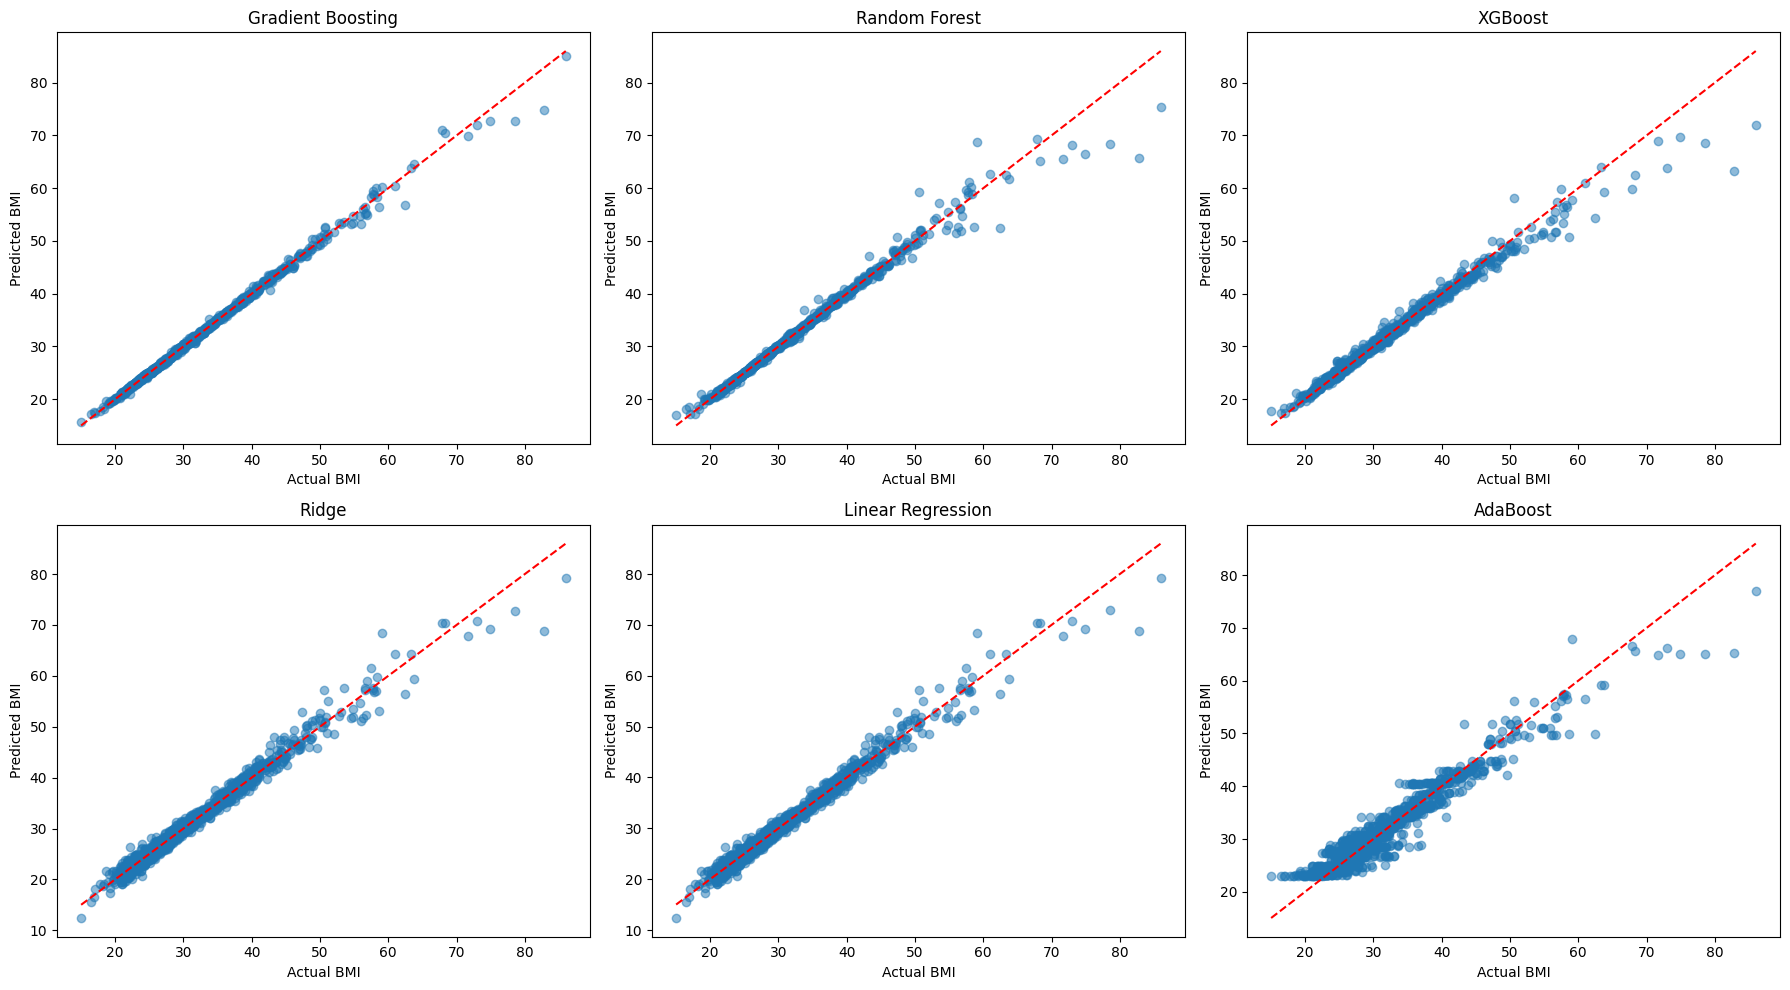

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for plot_idx, (_, row) in enumerate(results_df.iterrows()):

    preds = row['Predictions']

    axes[plot_idx].scatter(
        y_test,
        preds,
        alpha=0.5
    )

    axes[plot_idx].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )

    axes[plot_idx].set_title(row['Model'])

    axes[plot_idx].set_xlabel('Actual BMI')

    axes[plot_idx].set_ylabel('Predicted BMI')

plt.tight_layout()

plt.savefig(
    f'{RESULTS}/pred_vs_actual.png',
    dpi=150
)

plt.show()

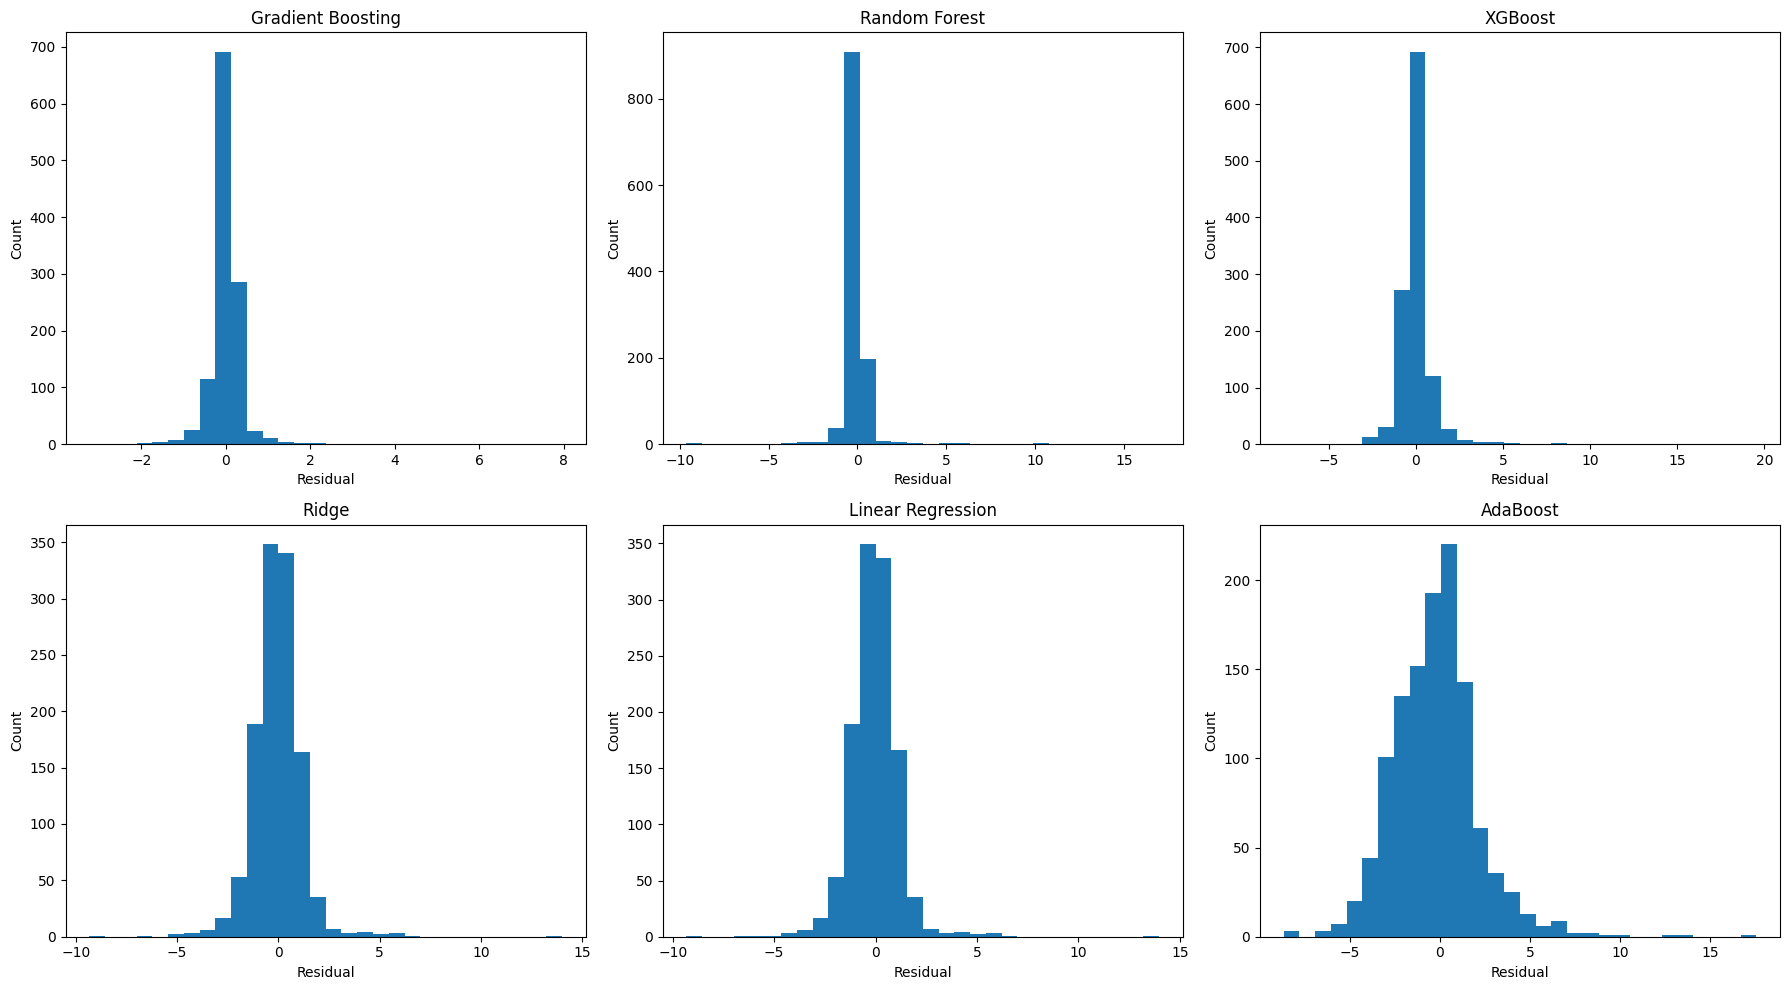

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for plot_idx, (_, row) in enumerate(results_df.iterrows()):

    preds = row['Predictions']

    residuals = y_test - preds

    axes[plot_idx].hist(
        residuals,
        bins=30
    )

    axes[plot_idx].set_title(row['Model'])

    axes[plot_idx].set_xlabel('Residual')

    axes[plot_idx].set_ylabel('Count')

plt.tight_layout()

plt.savefig(
    f'{RESULTS}/residual_plots.png',
    dpi=150
)

plt.show()

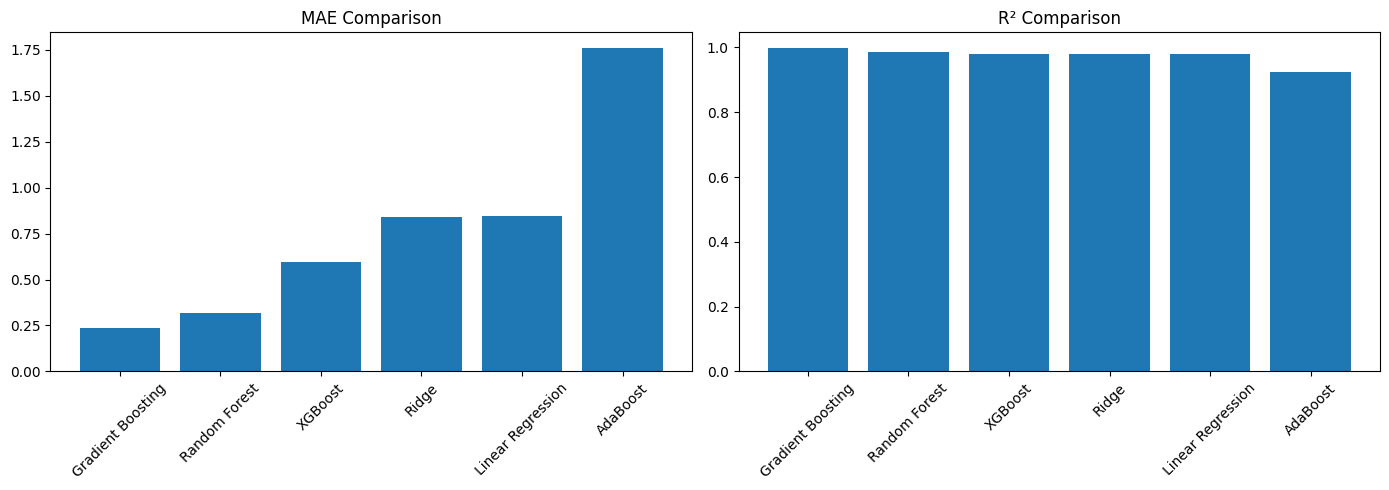

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE
axes[0].bar(
    results_df['Model'],
    results_df['MAE']
)

axes[0].set_title('MAE Comparison')

axes[0].tick_params(axis='x', rotation=45)

# R2
axes[1].bar(
    results_df['Model'],
    results_df['R2']
)

axes[1].set_title('R² Comparison')

axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.savefig(
    f'{RESULTS}/metric_comparison.png',
    dpi=150
)

plt.show()

In [10]:
best_row = results_df.iloc[0]

best_model = best_row['ModelObject']

best_name = best_row['Model']

save_path = f"{MODELS}/best_model.pkl"

joblib.dump(best_model, save_path)

print(f"✅ Best model saved: {best_name}")

print(f"Path: {save_path}")

✅ Best model saved: Gradient Boosting
Path: /drive/MyDrive/AI-Image-Analysis-Project/bmi_prediction/saved_models/best_model.pkl
